# ⚡ ESD Risk Prediction — Full Pipeline Notebook
### Explainable Attention-Based Situational Awareness Framework for Wearable IoT Devices

**Team roles covered:**
- 🔵 Member 1: Synthetic dataset generation (ESD physics simulation)
- 🟣 Member 2: Attention-based deep learning model (YOU)
- 🔴 Member 3: XAI — SHAP saliency + attention maps + Knowledge Graph

---
**Run this on Google Colab:** Runtime → Run all

In [1]:
# ── STEP 0: Install dependencies ─────────────────────────────
!pip install torch torchvision scikit-learn pandas numpy scipy matplotlib seaborn plotly streamlit -q
print('✓ Dependencies installed')

✓ Dependencies installed



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── STEP 1: Clone / set up project structure ─────────────────
import os, sys
from pathlib import Path

# If running in Colab, clone or upload the project files.
# Otherwise set ROOT to the local project path.
try:
    import google.colab
    IN_COLAB = True
    ROOT = Path('/content/esd_project')
    if not ROOT.exists():
        (ROOT / 'data').mkdir(parents=True, exist_ok=True)
        (ROOT / 'models').mkdir(parents=True, exist_ok=True)
        (ROOT / 'xai').mkdir(parents=True, exist_ok=True)
        (ROOT / 'dashboard').mkdir(parents=True, exist_ok=True)
        print('⚠ Colab detected. Please upload the project .py files or mount Drive.')
        print('  Expected structure:')
        print('    /content/esd_project/data/generate_dataset.py')
        print('    /content/esd_project/models/attention_model.py')
        print('    /content/esd_project/models/train.py')
        print('    /content/esd_project/xai/explainer.py')
except ImportError:
    IN_COLAB = False
    ROOT = Path.cwd().resolve()
    if ROOT.name == 'notebooks':
        ROOT = ROOT.parent
    while ROOT.parent != ROOT and not ((ROOT / 'data').exists() and (ROOT / 'models').exists()):
        ROOT = ROOT.parent
    if not ((ROOT / 'data').exists() and (ROOT / 'models').exists()):
        raise FileNotFoundError('Could not locate the esd_project root from the current notebook directory')

ROOT = str(ROOT)
sys.path.insert(0, ROOT)
print(f'✓ Project root: {ROOT}')

✓ Project root: D:\Downloads\esd_project\esd_project


## 🔵 Member 1 — Dataset Generation

In [3]:
# ── STEP 2: Generate synthetic ESD dataset ────────────────────
import runpy
dataset_globals = runpy.run_path(os.path.join(ROOT, 'data', 'generate_dataset.py'))
OUTPUT_PATH = dataset_globals['OUTPUT_PATH']
print('\n✓ Dataset saved to:', OUTPUT_PATH)

  ESD Dataset Generated Successfully
  Total samples : 15,000
  Output file   : D:\Downloads\esd_project\esd_project\data\esd_dataset.csv

  Risk distribution:
    Low      (0): 12,049  (80.3%)
    Medium   (1): 2,951  (19.7%)

✓ Dataset saved to: D:\Downloads\esd_project\esd_project\data\esd_dataset.csv


In [4]:
# ── STEP 3: Explore the dataset ───────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df = pd.read_csv(os.path.join(ROOT, 'data', 'esd_dataset.csv'))
print(df.describe().round(2).to_string())
print(f'\nShape: {df.shape}')
print('\nRisk label distribution:')
print(df['risk_label'].value_counts().sort_index().rename({0:'Low',1:'Medium',2:'High'}))

       humidity_pct  temperature_c  efield_vm  contact_voltage_v  movement_g  risk_score  risk_label
count      15000.00       15000.00   15000.00           15000.00    15000.00    15000.00     15000.0
mean          50.01          26.54     559.02             186.87        1.66        0.28         0.2
std           14.13           1.24     102.27              86.79        1.57        0.08         0.4
min           28.77          23.79     352.38              61.28        0.04        0.09         0.0
25%           36.05          25.53     483.84             126.20        0.11        0.22         0.0
50%           49.90          26.82     560.61             170.39        1.52        0.28         0.0
75%           64.19          27.64     626.22             238.79        2.80        0.34         0.0
max           71.14          28.36    1004.94             532.00        5.00        0.51         1.0

Shape: (15000, 11)

Risk label distribution:
risk_label
Low       12049
Medium     2951
Na

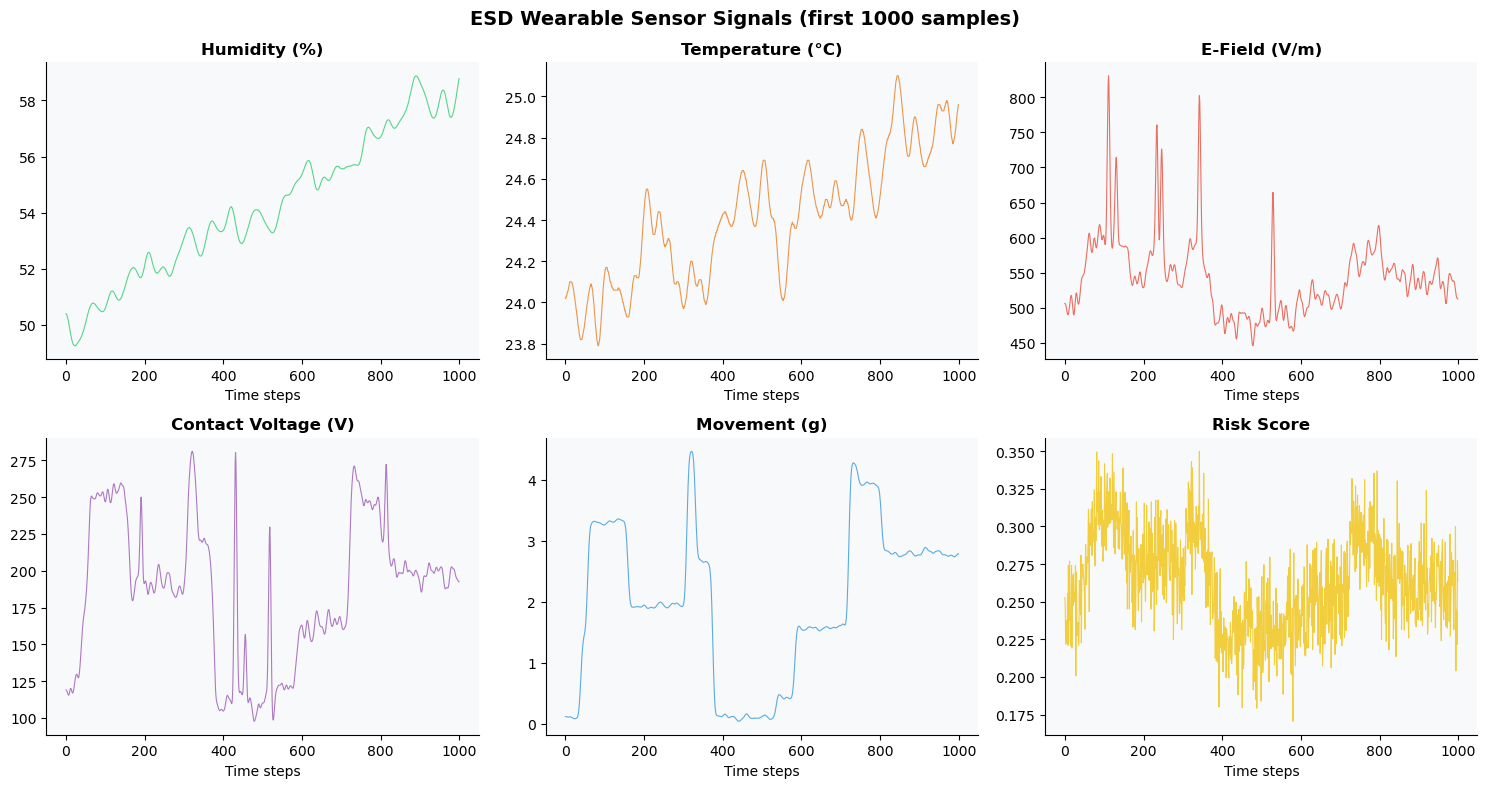

✓ Sensor overview plot saved


In [5]:
# ── STEP 4: Visualise sensor correlations with ESD risk ───────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sensors = ['humidity_pct', 'temperature_c', 'efield_vm', 'contact_voltage_v', 'movement_g', 'risk_score']
colors  = ['#2ecc71', '#e67e22', '#e74c3c', '#9b59b6', '#3498db', '#f1c40f']
titles  = ['Humidity (%)', 'Temperature (°C)', 'E-Field (V/m)', 'Contact Voltage (V)', 'Movement (g)', 'Risk Score']

for ax, col, color, title in zip(axes.flat, sensors, colors, titles):
    sample = df[col].iloc[:1000].values
    ax.plot(sample, color=color, linewidth=0.8, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time steps')
    ax.spines[['top','right']].set_visible(False)
    ax.set_facecolor('#f8f9fa')

plt.suptitle('ESD Wearable Sensor Signals (first 1000 samples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'xai', 'sensor_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Sensor overview plot saved')

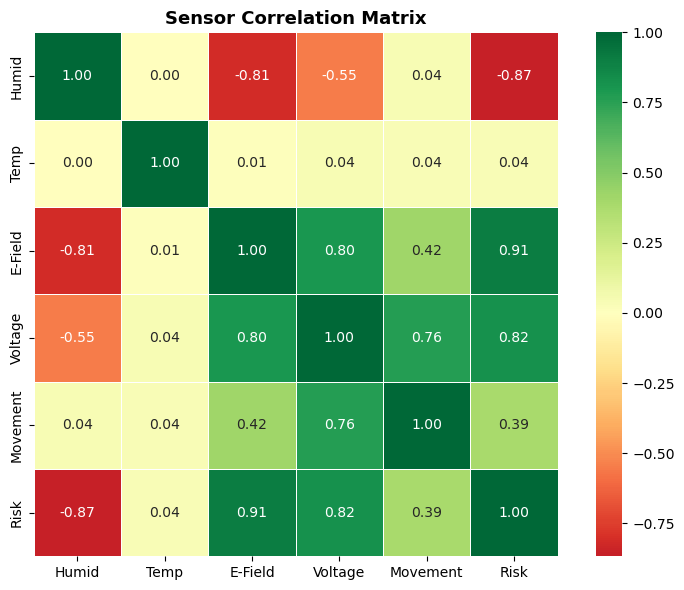

✓ Correlation heatmap saved


In [6]:
# ── STEP 5: Correlation heatmap ───────────────────────────────
import seaborn as sns

num_cols = ['humidity_pct','temperature_c','efield_vm','contact_voltage_v','movement_g','risk_score']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, square=True, linewidths=0.5,
            xticklabels=['Humid','Temp','E-Field','Voltage','Movement','Risk'],
            yticklabels=['Humid','Temp','E-Field','Voltage','Movement','Risk'])
ax.set_title('Sensor Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'xai', 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Correlation heatmap saved')

## 🟣 Member 2 — Attention Model Training

In [7]:
# ── STEP 6: Verify model architecture ────────────────────────
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
while ROOT.parent != ROOT and not (ROOT / 'models').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
from models.attention_model import build_model

model = build_model(window_size=50)
print(model)
print(f'\nTotal trainable parameters: {model.count_parameters():,}')

# Test forward pass
B, T = 4, 50
dummy_num  = torch.randn(B, T, 5)
dummy_cats = {
    'activity':    torch.randint(0, 4, (B,)),
    'environment': torch.randint(0, 4, (B,)),
    'fabric_type': torch.randint(0, 4, (B,)),
}
logits, attn = model(dummy_num, dummy_cats, return_attention=True)
print(f'\n✓ Forward pass OK')
print(f'  Input  : ({B}, {T}, 5)')
print(f'  Output : {logits.shape}  → 3 risk classes')
print(f'  Attn   : {len(attn)} layers × {attn[0].shape}')

ESDAttentionModel(
  (cat_embeddings): ModuleDict(
    (activity): Embedding(5, 8)
    (environment): Embedding(5, 8)
    (fabric_type): Embedding(5, 8)
  )
  (input_proj): Linear(in_features=5, out_features=64, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (attention_blocks): ModuleList(
    (0-1): 2 x AttentionBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (fusion_norm): LayerNorm((88,), eps=1e-05, elementwise_af

In [8]:
# ── STEP 7: Train the model ───────────────────────────────────
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
while ROOT.parent != ROOT and not (ROOT / 'models').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.train import train

model, results, scaler, encoders = train(epochs=30)
print('\n✓ Training complete')

Loading dataset...
  Train windows : 1,045
  Val windows   : 220
  Test windows  : 220

Model parameters: 73,515
Device          : cpu

Starting training for 30 epochs...
  Epoch 01/30 | loss 0.1078 | acc 0.9780 | val_f1 1.0000 | 2.3s
  Epoch 02/30 | loss 0.0015 | acc 1.0000 | val_f1 1.0000 | 1.8s
  Epoch 03/30 | loss 0.0006 | acc 1.0000 | val_f1 1.0000 | 1.7s
  Epoch 04/30 | loss 0.0005 | acc 1.0000 | val_f1 1.0000 | 1.3s
  Epoch 05/30 | loss 0.0004 | acc 1.0000 | val_f1 1.0000 | 1.2s
  Epoch 06/30 | loss 0.0003 | acc 1.0000 | val_f1 1.0000 | 1.2s
  Epoch 07/30 | loss 0.0002 | acc 1.0000 | val_f1 1.0000 | 1.2s
  Epoch 08/30 | loss 0.0002 | acc 1.0000 | val_f1 1.0000 | 1.2s

  Early stopping at epoch 8

────────────────────────────────────────
  Test Results
────────────────────────────────────────
  Accuracy  : 1.0000
  Macro F1  : 1.0000
  AUC-ROC   : 0.0000

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       220
      Medium     

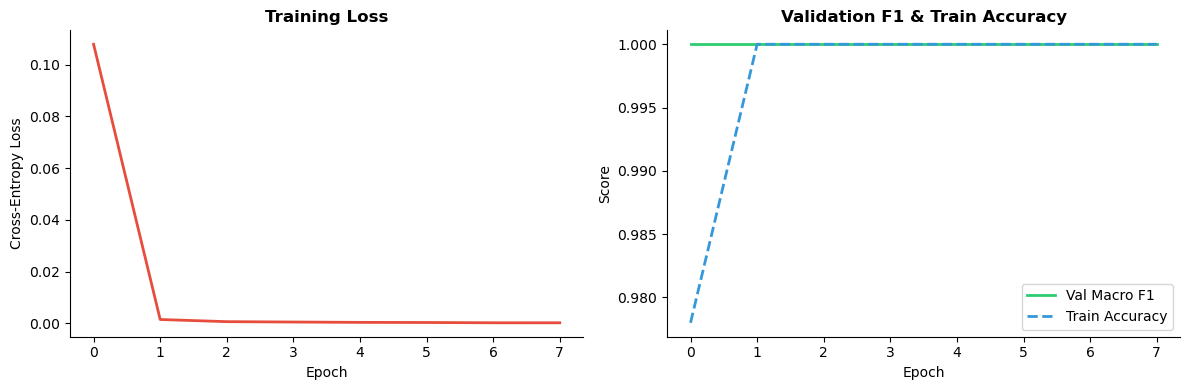


Final Test Results:
  Accuracy : 1.0000
  Macro F1 : 1.0000
  AUC-ROC  : 0.0000


In [9]:
# ── STEP 8: Plot training history ────────────────────────────
history = results['history']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], color='#e74c3c', linewidth=2, label='Train Loss')
ax1.set_title('Training Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.spines[['top','right']].set_visible(False)

ax2.plot(history['val_f1'], color='#2ecc71', linewidth=2, label='Val Macro F1')
ax2.plot(history['train_acc'], color='#3498db', linewidth=2, label='Train Accuracy', linestyle='--')
ax2.set_title('Validation F1 & Train Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.legend(); ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'xai', 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFinal Test Results:')
print(f'  Accuracy : {results["accuracy"]:.4f}')
print(f'  Macro F1 : {results["f1"]:.4f}')
print(f'  AUC-ROC  : {results["auc"]:.4f}')

Loading dataset...
  Train windows : 1,045
  Val windows   : 220
  Test windows  : 220

  Baseline Model Comparisons
  Skipping baselines: only one class is present in the windowed data (0).

── Model Comparison Table ──
                        accuracy   f1
Attention Model (Ours)       1.0  1.0


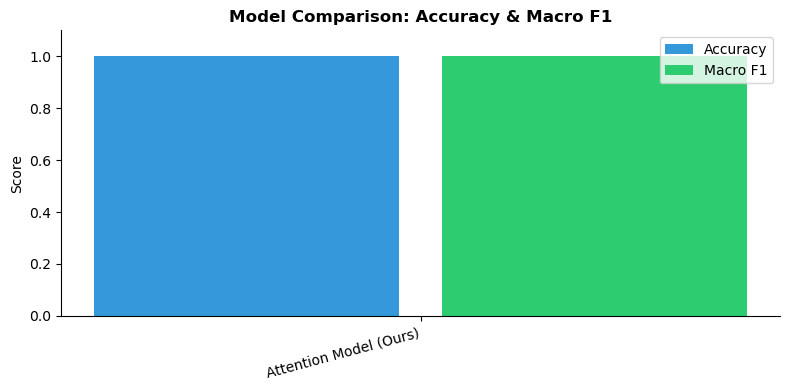

In [10]:
# ── STEP 9: Baseline comparison ───────────────────────────────
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
while ROOT.parent != ROOT and not (ROOT / 'models').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.train import prepare_data, run_baselines
_, _, test_loader, _, _, _, test_ds = prepare_data()
baseline_results = run_baselines(test_ds)

# Comparison table
comparison = {
    'Attention Model (Ours)': {'accuracy': results['accuracy'], 'f1': results['f1']},
    **baseline_results
}

comp_df = pd.DataFrame(comparison).T.round(4)
print('\n── Model Comparison Table ──')
print(comp_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(comp_df))
bars1 = ax.bar([i-0.2 for i in x], comp_df['accuracy'], 0.35, label='Accuracy', color='#3498db')
bars2 = ax.bar([i+0.2 for i in x], comp_df['f1'], 0.35, label='Macro F1', color='#2ecc71')
ax.set_xticks(list(x)); ax.set_xticklabels(comp_df.index, rotation=15, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy & Macro F1', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'xai', 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 🔴 Member 3 — XAI Analysis

In [11]:
# # ── STEP 10: Feature importance (gradient saliency) ───────────
# import sys
# from pathlib import Path

# ROOT = Path.cwd().resolve()
# if ROOT.name == 'notebooks':
#     ROOT = ROOT.parent
# while ROOT.parent != ROOT and not (ROOT / 'models').exists():
#     ROOT = ROOT.parent
# if str(ROOT) not in sys.path:
#     sys.path.insert(0, str(ROOT))

# from xai.explainer import compare_explainer_runtime, plot_global_importance
# from models.train import prepare_data, DEVICE

# train_loader, val_loader, test_loader, _, _, _, _ = prepare_data()
# model = model.to(DEVICE)

# runtime = compare_explainer_runtime(model, test_loader, DEVICE, n_batches=20)
# importance = runtime['gradient_importance']



# print('Explainer Runtime:')
# print(f"  GradientExplainer : {runtime['gradient_seconds']:.2f}s")
# print(f"  SHAPExplainer     : {runtime['shap_seconds']:.2f}s")
# print(f"  SHAP / Gradient   : {runtime['speedup']:.1f}x slower")

# print('Global Feature Importance:')
# for feat, imp in zip(['Humidity','Temperature','E-Field','Voltage','Movement'], importance):
#     bar = '█ ' * int(imp / importance.max() * 20)
#     print(f'  {feat:20s} {bar} {imp:.4f}')

# path = plot_global_importance(importance)
# from IPython.display import Image
# Image(path)

Loading dataset...
  Train windows : 1,045
  Val windows   : 220
  Test windows  : 220
Explainer Runtime:
  GradientExplainer : 0.10s
  SHAPExplainer     : 4.85s
  SHAP / Gradient   : 50.2x slower

Gradient Feature Importance:
  Humidity             █ █ █ █ █ █ █ █ █ █  0.0019
  Temperature          █ █ █ █ █ █ █ █ █ █ █ █ █ █ █ █ █ █ █ █  0.0037
  E-Field              █ █ █ █ █  0.0011
  Voltage              █ █ █ █ █  0.0010
  Movement             █ █ █ █ █ █ █ █ █ █  0.0019

SHAP Feature Importance:
  Humidity             █ █ █ █ █ █ █  0.0014
  Temperature          █ █ █ █ █ █ █ █ █ █ █ █ █ █ █ █ █ █ █ █  0.0038
  E-Field              █ █ █ █  0.0008
  Voltage              █ █ █  0.0006
  Movement             █ █ █ █ █ █ █ █ █  0.0018
  Saved: D:\Downloads\esd_project\esd_project\xai\gradient_importance.png
  Saved: D:\Downloads\esd_project\esd_project\xai\shap_importance.png


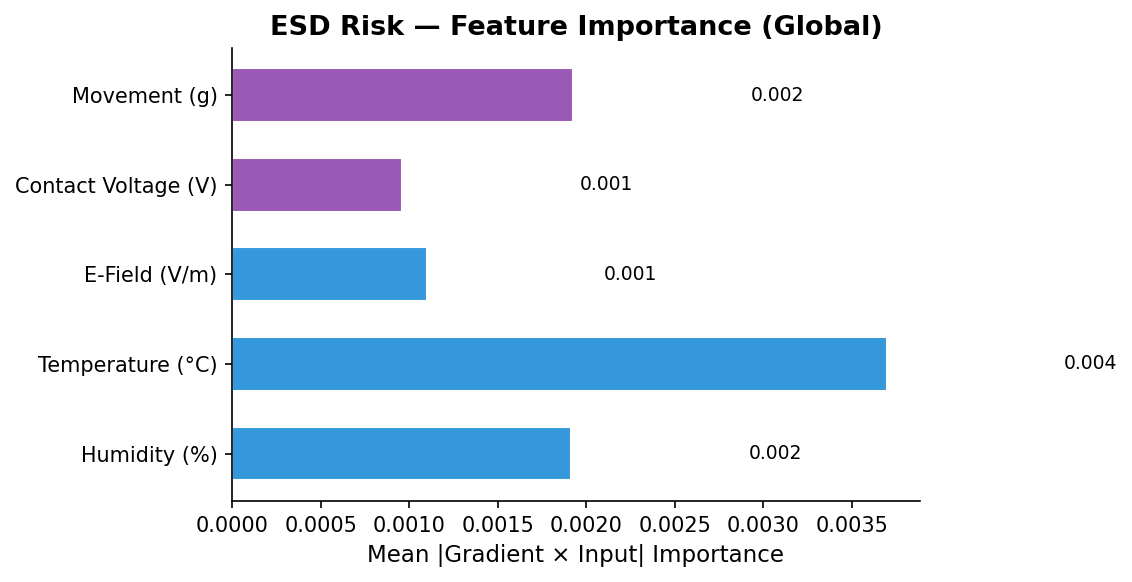

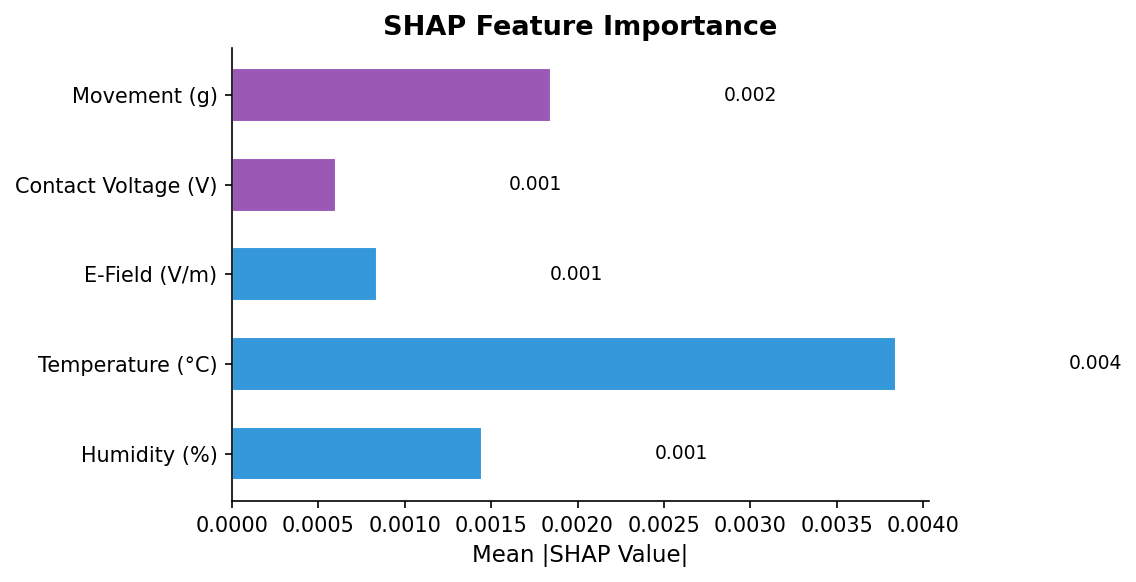

In [12]:
# ── STEP 10: Feature importance (Gradient Saliency + SHAP) ───────────
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
while ROOT.parent != ROOT and not (ROOT / 'models').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from xai.explainer import compare_explainer_runtime, plot_global_importance
from models.train import prepare_data, DEVICE

train_loader, val_loader, test_loader, _, _, _, _ = prepare_data()
model = model.to(DEVICE)

runtime = compare_explainer_runtime(model, test_loader, DEVICE, n_batches=20)

gradient_importance = runtime["gradient_importance"]
shap_importance = runtime["shap_importance"]

features = ["Humidity", "Temperature", "E-Field", "Voltage", "Movement"]

print("Explainer Runtime:")
print(f"  GradientExplainer : {runtime['gradient_seconds']:.2f}s")
print(f"  SHAPExplainer     : {runtime['shap_seconds']:.2f}s")
print(f"  SHAP / Gradient   : {runtime['speedup']:.1f}x slower")

print("\nGradient Feature Importance:")
for feat, imp in zip(features, gradient_importance):
    bar = "█ " * int(imp / gradient_importance.max() * 20)
    print(f"  {feat:20s} {bar} {imp:.4f}")

print("\nSHAP Feature Importance:")
for feat, imp in zip(features, shap_importance):
    bar = "█ " * int(imp / shap_importance.max() * 20)
    print(f"  {feat:20s} {bar} {imp:.4f}")

# Plot Gradient importance
gradient_path = plot_global_importance(
    gradient_importance,
    xlabel="Mean |Gradient × Input| Importance",
    filename="gradient_importance.png",
)

# Plot SHAP importance
shap_path = plot_global_importance(
    shap_importance,
    title="SHAP Feature Importance",
    xlabel="Mean |SHAP Value|",
    filename="shap_importance.png",
)

from IPython.display import Image, display

display(Image(gradient_path))
display(Image(shap_path))

  Saved: D:\Downloads\esd_project\esd_project\xai\attention_map.png


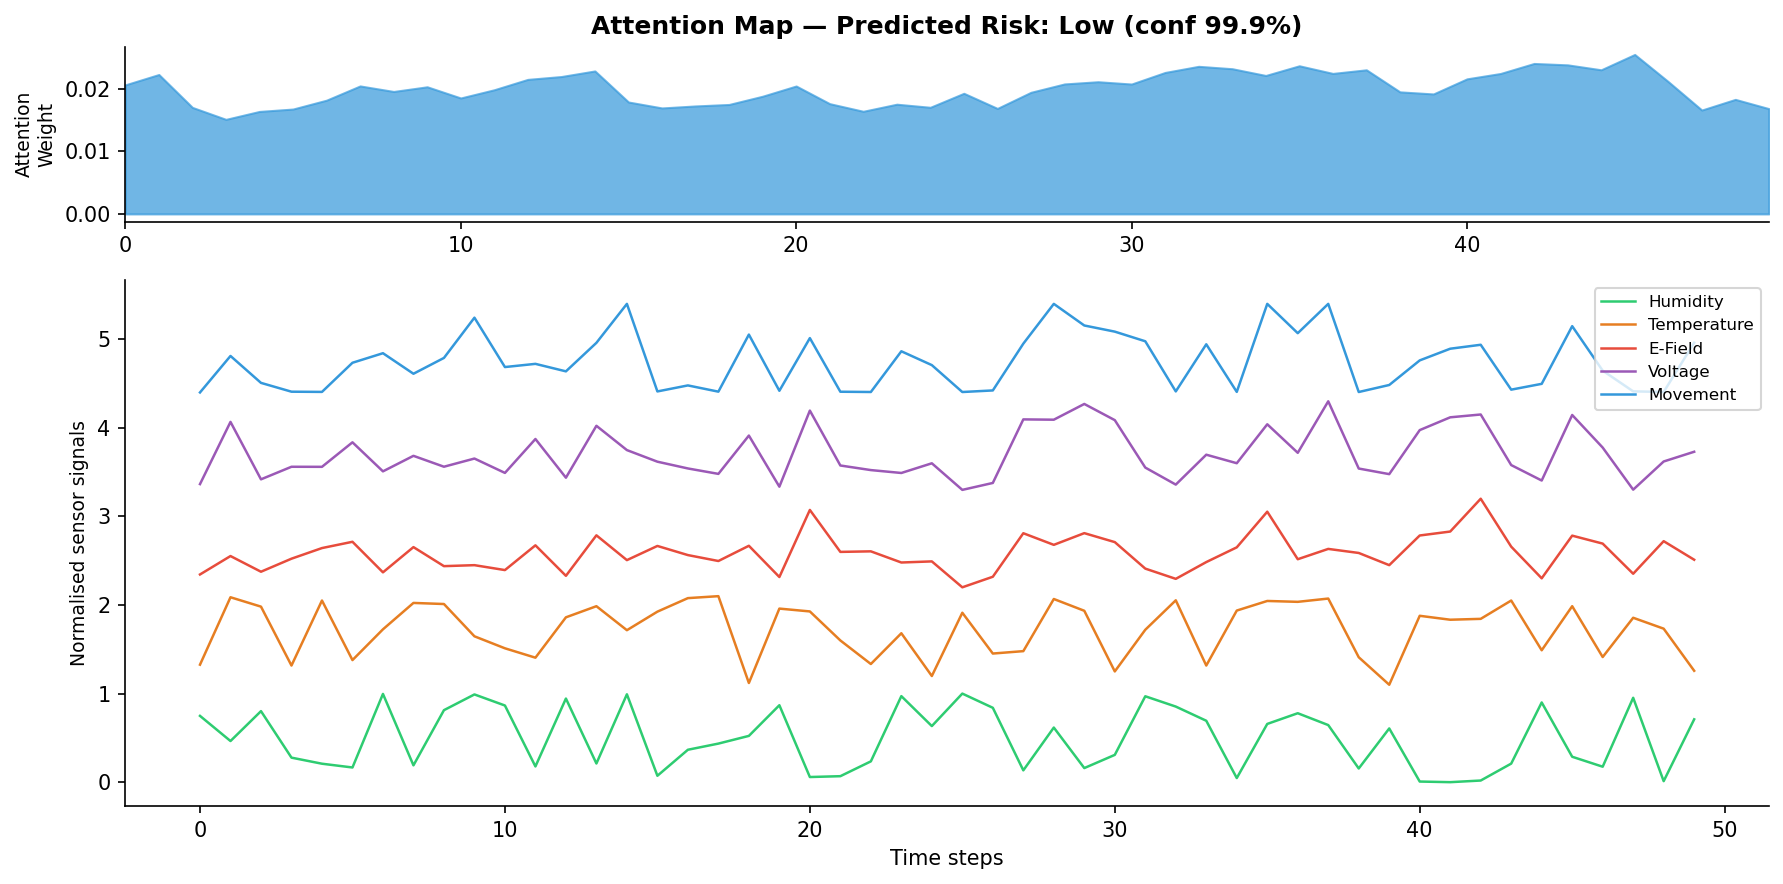

In [13]:
# ── STEP 11: Attention map for one sample ─────────────────────
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
while ROOT.parent != ROOT and not (ROOT / 'models').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from xai.explainer import plot_attention_map

# Pick one test sample
sample_num, sample_cats, sample_lbl = next(iter(test_loader))
idx = 0
single_num  = sample_num[idx:idx+1]
single_cats = {k: v[idx:idx+1] for k, v in sample_cats.items()}

path = plot_attention_map(model, single_num, single_cats, DEVICE)
Image(path)

In [14]:
# ── STEP 12: Plain-English explanation ───────────────────────
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
while ROOT.parent != ROOT and not (ROOT / 'models').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from xai.explainer import generate_explanation, RISK_LABELS
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    logits = model(single_num.to(DEVICE), {k: v.to(DEVICE) for k, v in single_cats.items()})
    probs  = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

pred_class = int(probs.argmax())

# Use last raw sensor reading as context
df_sample = pd.read_csv(os.path.join(ROOT, 'data', 'esd_dataset.csv'))
sample_row = df_sample.iloc[5000]
sensor_ctx = {
    'humidity_pct':      sample_row['humidity_pct'],
    'temperature_c':     sample_row['temperature_c'],
    'efield_vm':         sample_row['efield_vm'],
    'contact_voltage_v': sample_row['contact_voltage_v'],
    'movement_g':        sample_row['movement_g'],
    'activity':          sample_row['activity'],
    'environment':       sample_row['environment'],
    'fabric_type':       sample_row['fabric_type'],
}

explanation = generate_explanation(sensor_ctx, pred_class, probs)
print(explanation)

⚡ ESD RISK PREDICTION: LOW (99.9% confidence)
──────────────────────────────────────────────────

📊 SENSOR ANALYSIS:
  • Humidity 68% — Normal. Helps dissipate static charge.
  • E-Field 399 V/m — Normal range.
  • Contact voltage 91 V — Low.
  • Movement 0.68 g — Minimal motion.

🔗 CONTEXT REASONING (Knowledge Graph):
  • Fabric [wool] is a HIGH triboelectric generator → elevated base risk.
  • Environment [office] likely has sensitive electronics nearby → higher impact risk.

🛡️ RECOMMENDED ACTIONS:
  ✓ Conditions are currently safe.
  → Continue monitoring — conditions can change rapidly.


In [15]:
# ── STEP 13: Knowledge Graph visualisation ───────────────────
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
while ROOT.parent != ROOT and not (ROOT / 'models').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from xai.explainer import get_knowledge_graph
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

kg = get_knowledge_graph()

# Simple force-directed layout approximation
positions = {
    'ESD_Risk':            (0.5,  0.5),
    'Humidity':            (0.1,  0.8),
    'ElectricField':       (0.2,  0.3),
    'ContactVoltage':      (0.8,  0.3),
    'Movement':            (0.9,  0.7),
    'Polyester':           (0.95, 0.5),
    'Wool':                (0.85, 0.15),
    'Synthetic':           (0.75, 0.08),
    'Cotton':              (0.65, 0.15),
    'Lab':                 (0.3,  0.9),
    'Office':              (0.15, 0.65),
    'HandlingElectronics': (0.5,  0.85),
    'WristStrap':          (0.1,  0.35),
    'Grounding':           (0.2,  0.15),
    'HumidityControl':     (0.4,  0.1),
}

type_colors = {'concept':'#e74c3c','sensor':'#3498db','material':'#9b59b6',
               'environment':'#2ecc71','activity':'#f39c12','mitigation':'#1abc9c'}

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('#1a1a2e')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.axis('off')

# Draw edges
for edge in kg['edges']:
    x0, y0 = positions[edge['from']]
    x1, y1 = positions[edge['to']]
    color = '#e74c3c' if edge['weight'] > 0 else '#2ecc71'
    alpha = min(0.9, abs(edge['weight']) * 1.2)
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
        arrowprops=dict(arrowstyle='->', color=color, alpha=alpha, lw=1.5))
    mx, my = (x0+x1)/2, (y0+y1)/2
    ax.text(mx, my, edge['relation'].replace('_',' '), fontsize=5,
            color='#aaaaaa', ha='center', va='center', alpha=0.7)

# Draw nodes
for node in kg['nodes']:
    x, y = positions[node['id']]
    color = type_colors.get(node['type'], '#888')
    size  = 800 if node['id'] == 'ESD_Risk' else 400
    ax.scatter(x, y, s=size, c=color, zorder=5, edgecolors='white', linewidths=1.5)
    ax.text(x, y-0.05, node['id'].replace('_',' '), fontsize=7,
            ha='center', va='top', color='white', fontweight='bold')

# Legend
patches = [mpatches.Patch(color=v, label=k) for k, v in type_colors.items()]
ax.legend(handles=patches, loc='lower left', fontsize=8,
          facecolor='#2d2d44', labelcolor='white', edgecolor='#555')

ax.set_title('ESD Knowledge Graph — Risk Reasoning Network',
             color='white', fontsize=13, fontweight='bold', pad=15)
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'xai', 'knowledge_graph.png'), dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✓ Knowledge Graph saved')

✓ Knowledge Graph saved


C:\Users\Rishi\AppData\Local\Temp\ipykernel_15656\4196158015.py:78: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Knowledge Graph Usage Example

This example shows how sensor and context values are converted into active KG nodes, traced to `ESD_Risk`, and used to choose mitigation actions.


In [ ]:
# STEP 14: Knowledge Graph reasoning example
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
while ROOT.parent != ROOT and not (ROOT / 'xai').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from xai.explainer import get_knowledge_graph

kg = get_knowledge_graph()

example_context = {
    'humidity_pct': 24,
    'efield_vm': 2200,
    'contact_voltage_v': 620,
    'movement_g': 2.9,
    'fabric_type': 'wool',
    'environment': 'lab',
    'activity': 'handling_electronics',
}

context_to_node = {
    'humidity_pct': 'Humidity',
    'efield_vm': 'ElectricField',
    'contact_voltage_v': 'ContactVoltage',
    'movement_g': 'Movement',
    'fabric_type': example_context['fabric_type'].title(),
    'environment': example_context['environment'].title(),
    'activity': 'HandlingElectronics',
}

active_nodes = []
if example_context['humidity_pct'] < 30:
    active_nodes.append(context_to_node['humidity_pct'])
if example_context['efield_vm'] > 2000:
    active_nodes.append(context_to_node['efield_vm'])
if example_context['contact_voltage_v'] > 500:
    active_nodes.append(context_to_node['contact_voltage_v'])
if example_context['movement_g'] > 2.5:
    active_nodes.append(context_to_node['movement_g'])
active_nodes.extend([
    context_to_node['fabric_type'],
    context_to_node['environment'],
    context_to_node['activity'],
])
active_nodes = list(dict.fromkeys(active_nodes))

edges_from = {}
for edge in kg['edges']:
    edges_from.setdefault(edge['from'], []).append(edge)

def find_paths(start, target='ESD_Risk', max_depth=3):
    paths = []

    def walk(node, path, seen):
        if len(path) > max_depth:
            return
        for edge in edges_from.get(node, []):
            next_node = edge['to']
            next_path = path + [edge]
            if next_node == target:
                paths.append(next_path)
            elif next_node not in seen:
                walk(next_node, next_path, seen | {next_node})

    walk(start, [], {start})
    return paths

print('KG reasoning example: dry lab electronics handling')
print('=' * 58)
print('Active evidence nodes:')
for node in active_nodes:
    print(f'  - {node}')

print('\nRisk paths found in the KG:')
path_count = 0
risk_contribution = 0.0
for node in active_nodes:
    for path in find_paths(node):
        path_count += 1
        relation_text = []
        path_score = 1.0
        current = node
        for edge in path:
            relation_text.append(f"{current} --{edge['relation']} ({edge['weight']:+.2f})--> {edge['to']}")
            path_score *= edge['weight']
            current = edge['to']
        risk_contribution += path_score
        print(f"  {path_count}. " + ' | '.join(relation_text))

print(f'\nApproximate signed KG contribution: {risk_contribution:+.3f}')

mitigations = [edge for edge in kg['edges'] if edge['to'] == 'ESD_Risk' and edge['weight'] < 0]
print('\nMitigation nodes suggested by KG:')
for edge in sorted(mitigations, key=lambda e: e['weight']):
    print(f"  - {edge['from']} mitigates ESD_Risk ({edge['weight']:+.2f})")


In [16]:
# ── STEP 15: Launch dashboard ────────────────────────────────
print('To launch the real-time dashboard, run:')
print('  streamlit run dashboard/app.py')
print('')
print('In Google Colab, use:')
print('  !pip install streamlit pyngrok -q')
print('  from pyngrok import ngrok')
print('  !streamlit run dashboard/app.py &')
print('  ngrok.connect(8501)')
print('')
print('=' * 55)
print('  ✅ ALL PIPELINE STEPS COMPLETE')
print('=' * 55)
print('  Outputs saved:')
import os, glob
for f in sorted(glob.glob(os.path.join(ROOT, 'xai', '*.png'))):
    print(f'    {f}')
print(f'    {os.path.join(ROOT, "models", "best_model.pt")}')
print(f'    {os.path.join(ROOT, "data", "esd_dataset.csv")}')

To launch the real-time dashboard, run:
  streamlit run dashboard/app.py

In Google Colab, use:
  !pip install streamlit pyngrok -q
  from pyngrok import ngrok
  !streamlit run dashboard/app.py &
  ngrok.connect(8501)

  ✅ ALL PIPELINE STEPS COMPLETE
  Outputs saved:
    D:\Downloads\esd_project\esd_project\xai\01_sensor_overview.png
    D:\Downloads\esd_project\esd_project\xai\02_class_distribution.png
    D:\Downloads\esd_project\esd_project\xai\03_correlation_heatmap.png
    D:\Downloads\esd_project\esd_project\xai\04_training_history.png
    D:\Downloads\esd_project\esd_project\xai\05_model_comparison.png
    D:\Downloads\esd_project\esd_project\xai\06_feature_importance.png
    D:\Downloads\esd_project\esd_project\xai\07_attention_map.png
    D:\Downloads\esd_project\esd_project\xai\08_knowledge_graph.png
    D:\Downloads\esd_project\esd_project\xai\09_ablation_study.png
    D:\Downloads\esd_project\esd_project\xai\10_multilayer_attention.png
    D:\Downloads\esd_project\esd_proje